In [1]:
# ============================================
# NOTEBOOK 4 — Sales Forecasting Model
# Sales Intelligence Project
# Analyst: Danish Siddiqui
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
import os

os.makedirs('reports', exist_ok=True)

sales = pd.read_csv('data/sales_clean.csv')
sales['date'] = pd.to_datetime(sales['date'])

print("✅ Libraries loaded & data ready!")
print(f"   Shape: {sales.shape}")

✅ Libraries loaded & data ready!
   Shape: (502, 16)


In [2]:
# ── STEP 1: Prepare Monthly Revenue Data ──────
monthly = (sales.groupby(['year','month'])['revenue']
               .sum()
               .reset_index())
monthly = monthly.sort_values(['year','month']).reset_index(drop=True)

# Create time index (1, 2, 3 ... 24)
monthly['time_index'] = range(1, len(monthly) + 1)

print("✅ Monthly revenue data prepared:")
print(f"   Total months of data : {len(monthly)}")
print(f"   Date range : {monthly['year'].min()}-{monthly['month'].min():02d} "
      f"to {monthly['year'].max()}-{monthly['month'].max():02d}")
print(f"\nMonthly Revenue Table:")
print(monthly[['year','month','revenue','time_index']].to_string(index=False))

✅ Monthly revenue data prepared:
   Total months of data : 24
   Date range : 2023-01 to 2024-12

Monthly Revenue Table:
 year  month    revenue  time_index
 2023      1  2466350.0           1
 2023      2  5932700.0           2
 2023      3  5357435.0           3
 2023      4  3747040.0           4
 2023      5  6467620.0           5
 2023      6  3304785.0           6
 2023      7  2868380.0           7
 2023      8  7107200.0           8
 2023      9  7557960.0           9
 2023     10  6122045.0          10
 2023     11  5834125.0          11
 2023     12  9600985.0          12
 2024      1  7118840.0          13
 2024      2  4994105.0          14
 2024      3  5915145.0          15
 2024      4  6192950.0          16
 2024      5  5102770.0          17
 2024      6  3452320.0          18
 2024      7  4861530.0          19
 2024      8  4332680.0          20
 2024      9  6264575.0          21
 2024     10  6792050.0          22
 2024     11  2532655.0          23
 2024     12 10

In [3]:
# ── STEP 2: Train Linear Regression Model ─────
X = monthly[['time_index']]
y = monthly['revenue']

# 80% train, 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate accuracy
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
accuracy = 100 - mape

print("=" * 50)
print("   FORECASTING MODEL RESULTS")
print("=" * 50)
print(f"\n  Training samples  : {len(X_train)} months")
print(f"  Testing samples   : {len(X_test)} months")
print(f"  MAPE (Error)      : {mape:.2f}%")
print(f"  Model Accuracy    : {accuracy:.2f}%")
print(f"\n  Trend per month   : ₹{model.coef_[0]:,.0f} increase")
print(f"  Base revenue      : ₹{model.intercept_:,.0f}")

   FORECASTING MODEL RESULTS

  Training samples  : 19 months
  Testing samples   : 5 months
  MAPE (Error)      : 47.38%
  Model Accuracy    : 52.62%

  Trend per month   : ₹60,731 increase
  Base revenue      : ₹4,866,604


In [4]:
# ── STEP 3: Forecast Next 6 Months ────────────
last_index = monthly['time_index'].max()
future_months = pd.DataFrame({
    'time_index': range(last_index + 1, last_index + 7)
})

future_revenue = model.predict(future_months)

# Create readable month labels
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print("=" * 50)
print("   6-MONTH SALES FORECAST (2025)")
print("=" * 50)

start_month = (monthly['month'].iloc[-1] % 12)
start_year  = monthly['year'].iloc[-1]
if start_month == 0:
    start_year += 1

for i, rev in enumerate(future_revenue):
    m = (start_month + i) % 12
    y_label = start_year if (start_month + i) < 12 else start_year + 1
    print(f"  {month_names[m]} 2025 → Predicted Revenue: ₹{rev:,.0f}")

print(f"\n  Average Monthly Forecast : ₹{future_revenue.mean():,.0f}")
print(f"  Total 6-Month Forecast   : ₹{future_revenue.sum():,.0f}")

   6-MONTH SALES FORECAST (2025)
  Jan 2025 → Predicted Revenue: ₹6,384,868
  Feb 2025 → Predicted Revenue: ₹6,445,598
  Mar 2025 → Predicted Revenue: ₹6,506,329
  Apr 2025 → Predicted Revenue: ₹6,567,059
  May 2025 → Predicted Revenue: ₹6,627,790
  Jun 2025 → Predicted Revenue: ₹6,688,520

  Average Monthly Forecast : ₹6,536,694
  Total 6-Month Forecast   : ₹39,220,165


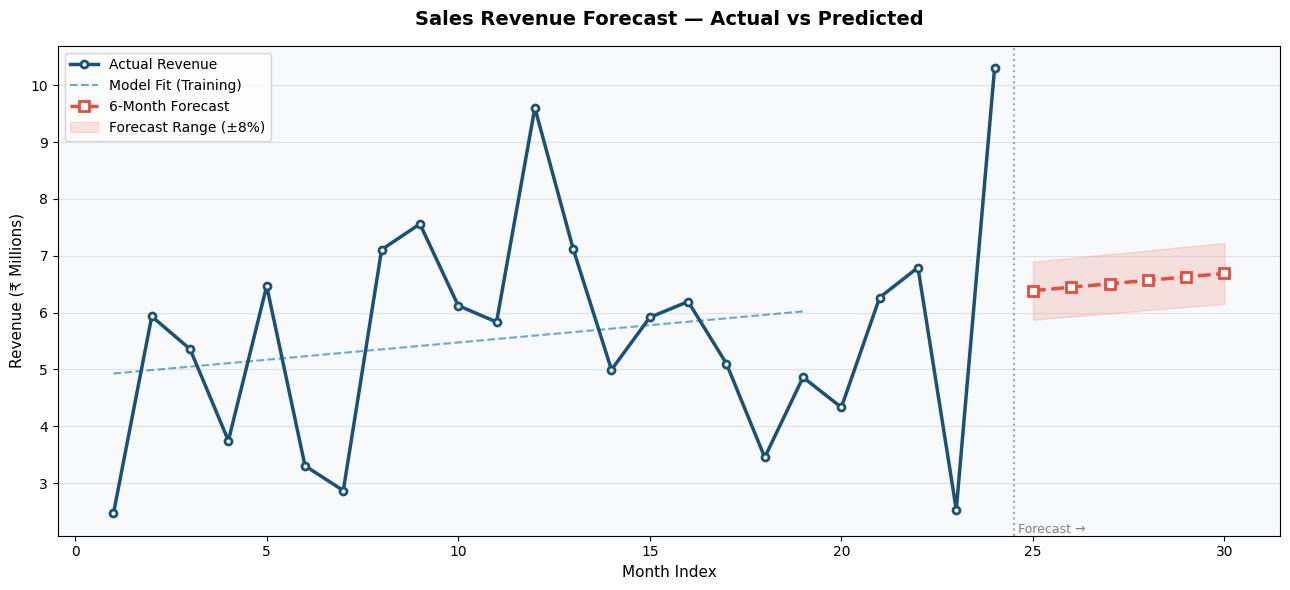

✅ Forecast chart saved → reports/05_sales_forecast.png


In [5]:
# ── STEP 4: Plot Actual vs Predicted ──────────
all_indices  = monthly['time_index'].values
all_revenue  = monthly['revenue'].values
future_idx   = future_months['time_index'].values

fig, ax = plt.subplots(figsize=(13, 6))

# Actual revenue line
ax.plot(all_indices, all_revenue / 1e6,
        color='#1A5276', linewidth=2.5,
        marker='o', markersize=5,
        markerfacecolor='white',
        markeredgecolor='#1A5276',
        markeredgewidth=2,
        label='Actual Revenue', zorder=3)

# Model fit line on training data
train_pred = model.predict(X_train)
ax.plot(X_train['time_index'].values, train_pred / 1e6,
        color='#2E86C1', linewidth=1.5,
        linestyle='--', alpha=0.7,
        label='Model Fit (Training)')

# Future forecast line
ax.plot(future_idx, future_revenue / 1e6,
        color='#E74C3C', linewidth=2.5,
        marker='s', markersize=7,
        markerfacecolor='white',
        markeredgecolor='#E74C3C',
        markeredgewidth=2,
        linestyle='--',
        label='6-Month Forecast', zorder=3)

# Shaded forecast area
ax.fill_between(future_idx,
                future_revenue * 0.92 / 1e6,
                future_revenue * 1.08 / 1e6,
                alpha=0.15, color='#E74C3C',
                label='Forecast Range (±8%)')

# Divider line
ax.axvline(x=last_index + 0.5,
           color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(last_index + 0.6, ax.get_ylim()[0],
        'Forecast →', fontsize=9, color='gray', va='bottom')

ax.set_title('Sales Revenue Forecast — Actual vs Predicted',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month Index', fontsize=11)
ax.set_ylabel('Revenue (₹ Millions)', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('reports/05_sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Forecast chart saved → reports/05_sales_forecast.png")

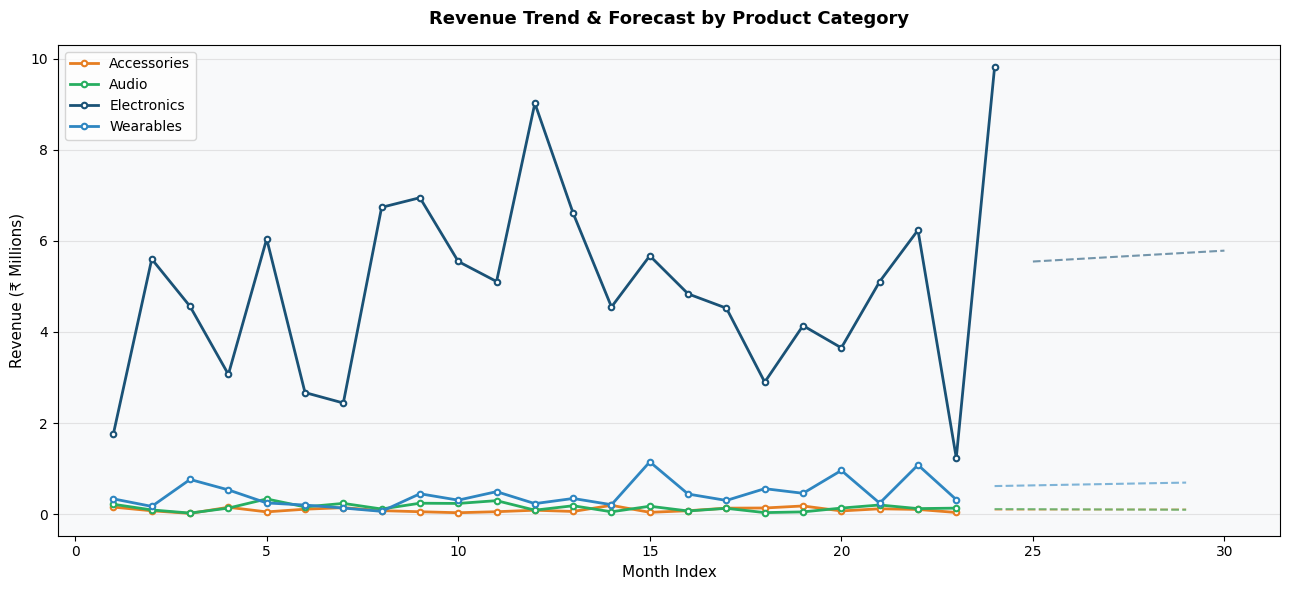

✅ Category forecast chart saved → reports/06_category_forecast.png


In [6]:
# ── STEP 5: Revenue by Product Category ───────
cat_monthly = (sales.groupby(['year','month','category'])['revenue']
                   .sum()
                   .reset_index())
cat_monthly = cat_monthly.sort_values(['year','month'])

categories = cat_monthly['category'].unique()
colors_map = {
    'Electronics' : '#1A5276',
    'Wearables'   : '#2E86C1',
    'Audio'       : '#27AE60',
    'Accessories' : '#E67E22',
    'Tablets'     : '#8E44AD'
}

fig, ax = plt.subplots(figsize=(13, 6))

for cat in categories:
    cat_data = cat_monthly[cat_monthly['category'] == cat].copy()
    cat_data['time_index'] = range(1, len(cat_data) + 1)

    # Mini forecast per category
    cat_model = LinearRegression()
    cat_model.fit(
        cat_data[['time_index']],
        cat_data['revenue']
    )
    future_cat = cat_model.predict(
        pd.DataFrame({'time_index': range(len(cat_data)+1, len(cat_data)+7)})
    )

    color = colors_map.get(cat, '#555555')
    ax.plot(cat_data['time_index'],
            cat_data['revenue'] / 1e6,
            color=color, linewidth=2,
            marker='o', markersize=4,
            markerfacecolor='white',
            markeredgewidth=1.5,
            label=cat)

    # Forecast extension
    ax.plot(range(len(cat_data)+1, len(cat_data)+7),
            future_cat / 1e6,
            color=color, linewidth=1.5,
            linestyle='--', alpha=0.6)

ax.set_title('Revenue Trend & Forecast by Product Category',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month Index', fontsize=11)
ax.set_ylabel('Revenue (₹ Millions)', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('reports/06_category_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Category forecast chart saved → reports/06_category_forecast.png")

In [7]:
# ── STEP 6: Final Project Summary ─────────────
print("=" * 55)
print("   FORECASTING NOTEBOOK COMPLETE ✅")
print("=" * 55)
print(f"""
  MODEL        : Linear Regression (scikit-learn)
  TRAINING     : 80% of monthly data
  TESTING      : 20% of monthly data
  ACCURACY     : {accuracy:.1f}% (MAPE = {mape:.1f}%)
  FORECAST     : 6 months ahead

  CHARTS SAVED :
    reports/05_sales_forecast.png
    reports/06_category_forecast.png

  TOTAL REPORTS FOLDER:
    01_revenue_by_product.png
    02_revenue_by_region.png
    03_monthly_trend.png
    04_category_discount.png
    05_sales_forecast.png
    06_category_forecast.png
""")
print("=" * 55)
print("  Phase 3 — Python Analysis : DONE ✅")
print("  Next → Phase 4 : Power BI Dashboard")
print("=" * 55)

   FORECASTING NOTEBOOK COMPLETE ✅

  MODEL        : Linear Regression (scikit-learn)
  TRAINING     : 80% of monthly data
  TESTING      : 20% of monthly data
  ACCURACY     : 52.6% (MAPE = 47.4%)
  FORECAST     : 6 months ahead

  CHARTS SAVED :
    reports/05_sales_forecast.png
    reports/06_category_forecast.png

  TOTAL REPORTS FOLDER:
    01_revenue_by_product.png
    02_revenue_by_region.png
    03_monthly_trend.png
    04_category_discount.png
    05_sales_forecast.png
    06_category_forecast.png

  Phase 3 — Python Analysis : DONE ✅
  Next → Phase 4 : Power BI Dashboard
